In [91]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.dates as mdates

In [92]:
df = pd.read_csv("metrics.csv", sep=";")

print(df.head(10))

   id            timestamp        cpu_uso cpu_frecuencia  mem_fisica  \
0   1  2025-04-10 11:01:26    60.98,58.98      2300,2300        81.0   
1   2  2025-04-10 11:06:27    90.16,87.92      2300,2300        80.0   
2   3  2025-04-10 11:06:53    57.89,60.80      2300,2300        81.0   
3   4  2025-04-10 11:11:22    78.24,92.57      2300,2300        82.0   
4   5  2025-04-10 11:11:30    41.61,85.13      2300,2300        82.0   
5   6  2025-04-10 12:10:42  100.00,100.00      2300,2300        54.0   
6   7  2025-04-10 12:11:12  100.00,100.00      2300,2300        63.0   
7   8  2025-04-10 12:15:43     99.97,2.41      2300,2300        81.0   
8   9  2025-04-10 12:16:12    80.96,14.05      2300,2300        82.0   
9  10  2025-04-10 12:20:44   99.93,100.00      2300,2300        86.0   

   mem_swap                                   interface_nombre  \
0      41.0  Wi-Fi 2,Ethernet 2,Wi-Fi 2-VirtualBox NDIS Lig...   
1      42.0  Wi-Fi 2,Wi-Fi 2-VirtualBox NDIS Light-Weight F...   
2      44

In [93]:
#Convertiendo datos a su tipo correspondiente y seprandolos.
df["tiempo"] = pd.to_datetime(df["timestamp"])
df["cpu_uso_0"], df["cpu_uso_1"] = zip(*df["cpu_uso"].str.split(",").map(lambda x: map(float, x)))
df["cpu_freq_0"], df["cpu_freq_1"] = zip(*df["cpu_frecuencia"].str.split(",").map(lambda x: map(float, x)))

df["mem_fisica_pocentaje"] = df["mem_fisica"].astype(float)
df["mem_swap_porcentaje"] = df["mem_swap"].astype(float)
df["disco_uso_procentaje"] = df["disk_uso_percent"].astype(float)
df["conexiones_activas"] = df["conexiones_activas"].astype(int)

procesos = []

for idx, row in df.iterrows():
    timestamp = row["timestamp"]
    nombres = row["procesos_nombres"].split(",")
    cpu_usos = list(map(float, row["procesos_cpu_uso"].split(",")))
    memorias = list(map(float, row["procesos_memoria"].split(",")))
    
    for nombre, cpu, mem in zip(nombres, cpu_usos, memorias):
        procesos.append({

            "timestamp": timestamp,

            "proceso": nombre,
            "cpu_uso": cpu,
            "memoria": mem
        })

procesos_df = pd.DataFrame(procesos)


trafico = []

for idx, row in df.iterrows():
    timestamp = row["timestamp"]
    
    nombres = row["interface_nombre"].split(",")
    downs = list(map(float, row["data_down"].split(",")))
    ups = list(map(float, row["data_up"].split(",")))

    for nombre, down, up in zip(nombres, downs, ups):
        trafico.append({
            "timestamp": timestamp,
            "interfaz": nombre,
            "data_down": down,
            "data_up": up
        })

trafico_df = pd.DataFrame(trafico)


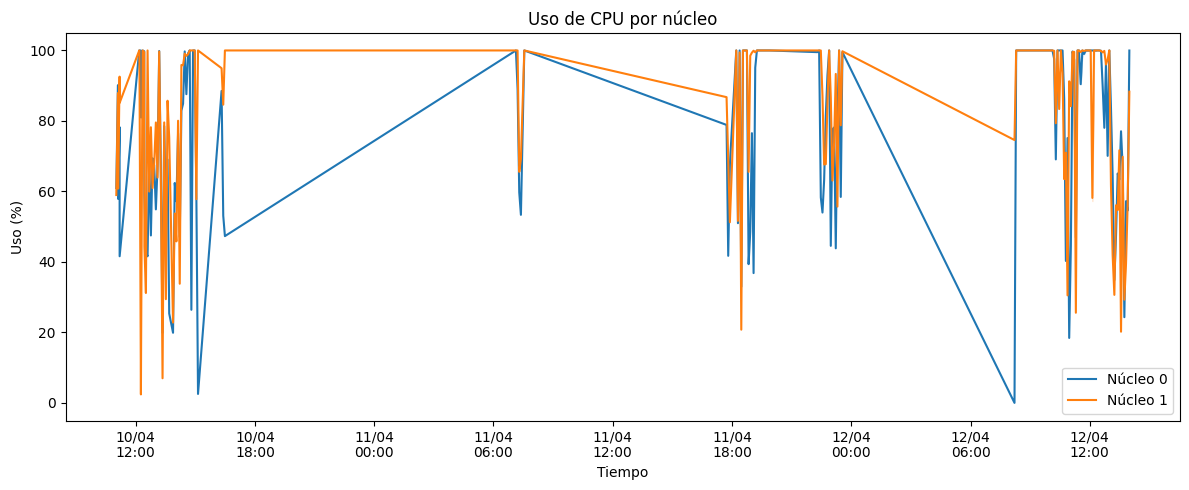

Núcleo 0 - Pico: 100.00%, Promedio: 77.48%
Núcleo 1 - Pico: 100.00%, Promedio: 81.41%


In [121]:
plt.figure(figsize=(12, 5))


sns.lineplot(x="tiempo", y="cpu_uso_0", data=df, label="Núcleo 0")
sns.lineplot(x="tiempo", y="cpu_uso_1", data=df, label="Núcleo 1")
plt.title("Uso de CPU por núcleo")
plt.xlabel("Tiempo")
plt.ylabel("Uso (%)")
plt.legend()

# Formato de fecha y hora
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%d/%m\n%H:%M'))
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

cpu0_max = df["cpu_uso_0"].max()
cpu0_avg = df["cpu_uso_0"].mean()
cpu1_max = df["cpu_uso_1"].max()
cpu1_avg = df["cpu_uso_1"].mean()

print(f"Núcleo 0 - Pico: {cpu0_max:.2f}%, Promedio: {cpu0_avg:.2f}%")
print(f"Núcleo 1 - Pico: {cpu1_max:.2f}%, Promedio: {cpu1_avg:.2f}%")

In [122]:
top_procesos_cpu = procesos_df.groupby("proceso")["cpu_uso"].mean().sort_values(ascending=False).head(5)
print(top_procesos_cpu)

proceso
powershell.exe            12.800000
RuntimeBroker.exe         10.610000
plugin-container.exe       7.687857
CrossDeviceService.exe     6.491667
audiodg.exe                6.315333
Name: cpu_uso, dtype: float64


C:\Users\Julio\AppData\Local\Temp\ipykernel_9964\2410339956.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_procesos_cpu.index, y=top_procesos_cpu.values, palette="rocket")


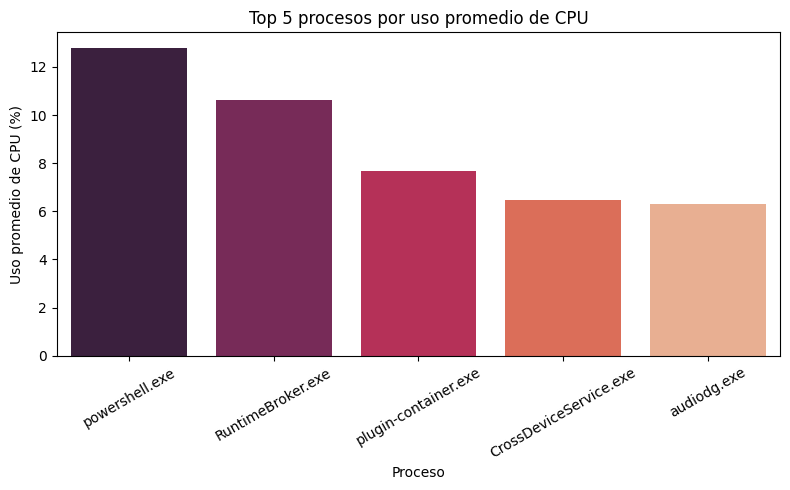

In [123]:
# Gráfica de barras
plt.figure(figsize=(8,5))
sns.barplot(x=top_procesos_cpu.index, y=top_procesos_cpu.values, palette="rocket")
plt.title("Top 5 procesos por uso promedio de CPU")
plt.xlabel("Proceso")
plt.ylabel("Uso promedio de CPU (%)")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

In [124]:
trafico_df.groupby("interfaz")[["data_down", "data_up"]].mean()
#top_procesos_cpu.groupby("proceso")[["cpu_uso", "memoria"]].mean()


,data_down,data_up
interfaz,,
Ethernet 2,0.000000,0.000000
Wi-Fi 2,131.391319,28.290694
Wi-Fi 2-VirtualBox NDIS Light-Weight Filter-0000,131.391250,28.290694


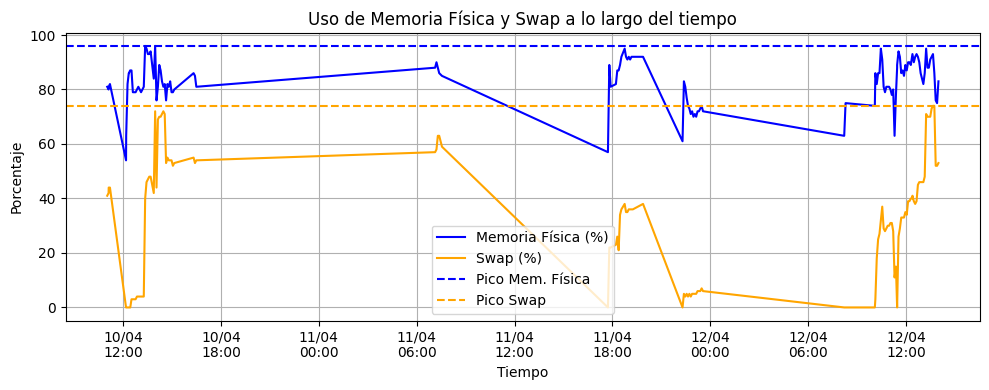

In [125]:
plt.figure(figsize=(10, 4))

# Línea de Memoria Física
plt.plot(df["tiempo"], df["mem_fisica_pocentaje"], label="Memoria Física (%)", color="blue")

# Línea de Memoria Swap
plt.plot(df["tiempo"], df["mem_swap_porcentaje"], label="Swap (%)", color="orange")

# Picos máximos
plt.axhline(df["mem_fisica_pocentaje"].max(), color='blue', linestyle='--', label="Pico Mem. Física")
plt.axhline(df["mem_swap_porcentaje"].max(), color='orange', linestyle='--', label="Pico Swap")

plt.title("Uso de Memoria Física y Swap a lo largo del tiempo")
plt.ylabel("Porcentaje")
plt.xlabel("Tiempo")
plt.legend()
plt.grid(True)

# Formato legible de fecha y hora
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%d/%m\n%H:%M'))
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()


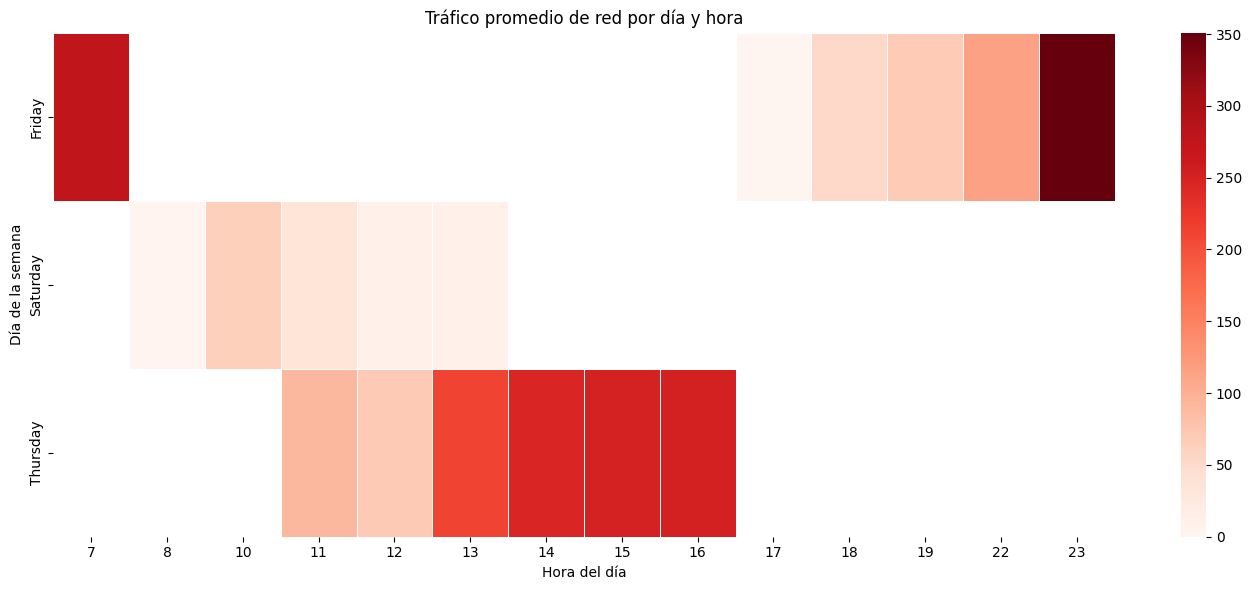

In [126]:
# Separamos el tiempo en dias y horas.
trafico_df["timestamp"] = pd.to_datetime(trafico_df["timestamp"])
trafico_df["dia_semana"] = trafico_df["timestamp"].dt.day_name()
trafico_df["hora"] = trafico_df["timestamp"].dt.hour

# Tomamos el trafico total
trafico_df["trafico_total"] = trafico_df["data_down"] + trafico_df["data_up"]

# Agrupamos por día y hora
heatmap_data = trafico_df.groupby(["dia_semana", "hora"])["trafico_total"].mean().reset_index()

# Ponemos los dias
dias_ordenados = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
heatmap_data["dia_semana"] = pd.Categorical(heatmap_data["dia_semana"], categories=dias_ordenados, ordered=True)


heatmap_pivot = heatmap_data.pivot(index="dia_semana", columns="hora", values="trafico_total")
plt.figure(figsize=(14, 6))
sns.heatmap(heatmap_pivot, cmap="Reds", annot=False, linewidths=0.5)
plt.title("Tráfico promedio de red por día y hora")
plt.xlabel("Hora del día")
plt.ylabel("Día de la semana")
plt.tight_layout()
plt.show()


Se espera un pico de CPU cada 22.0 horas.


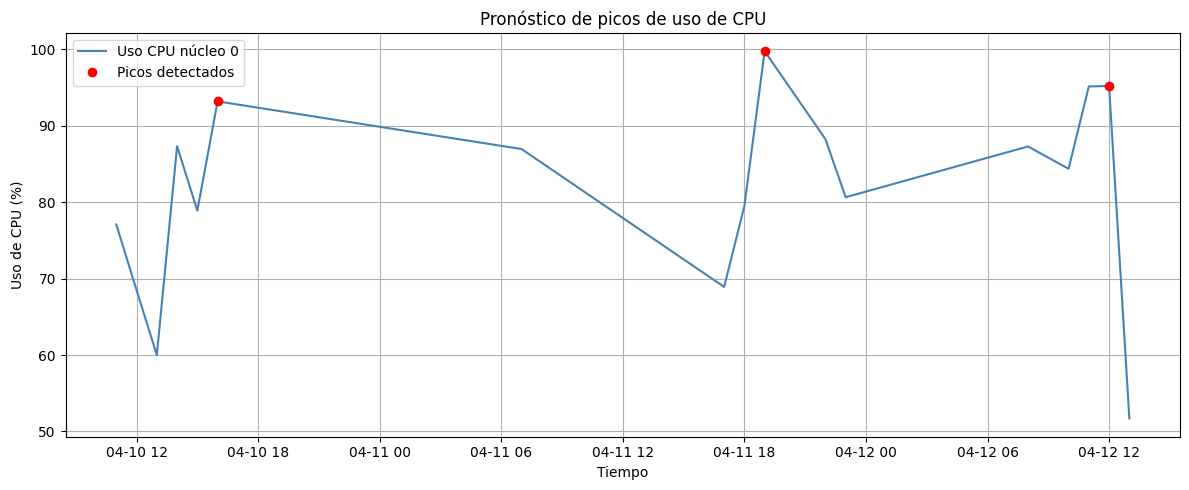

In [ ]:
import numpy as np
from scipy.signal import find_peaks

cpu = df[["tiempo", "cpu_uso_1"]].copy()
cpu["tiempo"] = pd.to_datetime(cpu["tiempo"])
cpu.set_index("tiempo", inplace=True)

cpu_h = cpu.resample("1H").mean().interpolate()
peaks, _ = find_peaks(cpu_h["cpu_uso_1"], height=np.percentile(cpu_h["cpu_uso_1"], 75))
tiempos_pico = cpu_h.index[peaks]

# Calcular intervalos entre picos
intervalos_horas = np.diff(tiempos_pico) / np.timedelta64(1, 'h') 
promedio_intervalo = np.mean(intervalos_horas)

# Resultado del análisis
print(f"Se espera un pico de CPU cada {promedio_intervalo:.1f} horas.")

# Gráfico
plt.figure(figsize=(12, 5))
plt.plot(cpu_h.index, cpu_h["cpu_uso_1"], label="Uso CPU núcleo 0", color='steelblue')
plt.plot(tiempos_pico, cpu_h.loc[tiempos_pico]["cpu_uso_1"], 'ro', label="Picos detectados")
plt.title("Pronóstico de picos de uso de CPU")
plt.xlabel("Tiempo")
plt.ylabel("Uso de CPU (%)")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()
